# Calculate vegetation onset and end for each pixel for each year using a GAM on the monthly temperature data

## 0. Load data

We select months Jan - Dec (1-12) for the northern hemisphere (lat >= 0) and months July - June next year (7-6) for the southern hemisphere because in the south the vegetation period is in the "winter" months. We load 12 months of data for each and estimate the vegetation period based on that. 

We select a pixel location and a 100x100 pixel window around it as an example region.

In [11]:
import glob
import numpy as np
import rasterio
from rasterio.transform import xy
from rasterio.warp import transform
from rasterio.transform import rowcol
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pygam import LinearGAM, s
from datetime import datetime, timedelta
import time
from tqdm import tqdm
import os
from rasterio.windows import Window

In [12]:
# TODO: Select desired year and location

# Year
year = 2002 # or leap year 2004

# Desired location (WGS84)
lon = 24  # near equator 29.9 # south africa 24 # altai 88.0 # europe 10.0 
lat = -27   # near equator -1.8 # south africa -27 # altai 49.0 # europe 50.0

### Define temporal extent

In [13]:
path = "/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly"

# Define months depending on hemisphere
if lat >= 0:
    months = list(range(1, 13))
    years = [year] * 12

else:
    months = list(range(7, 13)) + list(range(1, 7))
    years = [year] * 6 + [year + 1] * 6

print(months)
print(years)

# Create ordered file list
files_vegetation_year = []

for y, m in zip(years, months):
    pattern = os.path.join(
        path,
        f"Climate_monthly_{y}-{m:02d}-01.tif"
    )
    files_vegetation_year.append(pattern)

print(files_vegetation_year)

[7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]
[2002, 2002, 2002, 2002, 2002, 2002, 2003, 2003, 2003, 2003, 2003, 2003]
['/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2002-07-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2002-08-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2002-09-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2002-10-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2002-11-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2002-12-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2003-01-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2003-02-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2003-03-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly

### Define spatial extent

In [14]:
with rasterio.open(files_vegetation_year[0]) as src:

    # Convert lat/lon to raster CRS
    x, y = transform(
        "EPSG:4326",
        src.crs,
        [lon],
        [lat]
    )

    # Convert coordinates to pixel indices
    target_row, target_col = rowcol(
        src.transform,
        x[0],
        y[0]
    )

    # Create valid pixel mask
    band_names = list(src.descriptions)
    tmmn_band = band_names.index("tmmn") + 1

    tmmn = src.read(tmmn_band)
    valid_mask = tmmn != -9999

# Search radius around target pixel
radius = 10

candidates = []

for r in range(
    max(0, target_row - radius),
    min(valid_mask.shape[0], target_row + radius + 1)
):
    for c in range(
        max(0, target_col - radius),
        min(valid_mask.shape[1], target_col + radius + 1)
    ):
        if valid_mask[r, c]:
            distance = (r - target_row)**2 + (c - target_col)**2
            candidates.append((distance, r, c))

# Select nearest valid pixel
_, row, col = min(candidates)

print(f"Selected pixel: row={row}, col={col}")

Selected pixel: row=2599, col=4480


/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_64303/1372104437.py:22: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  tmmn = src.read(tmmn_band)


In [15]:
window_size = 100
half = window_size // 2

row_min = max(0, target_row - half)
row_max = min(valid_mask.shape[0], target_row + half)

col_min = max(0, target_col - half)
col_max = min(valid_mask.shape[1], target_col + half)

print(f"Window: row={row_min}:{row_max}, col={col_min}:{col_max}")

Window: row=2549:2649, col=4430:4530


## 1. Select minimum monthly temperatures

We calculate the day of the vegetation year of the middle day of each month. Because the doy is calculated relative to the vegetation period it works for both the northern and southern hemisphere. When it crosses the year boundary in the south, the doy continuously increases which is needed for the gam. 

For each middle day of month we assume the minimum temperature is the minimum monthly temperature. We extract the temperatures from the rasters and store them in a tensor of shape (12, 100, 100), i.e. (months, x, y).

Looking at the histograms it seems that temperatures are normally distributed overall, but not for individual pixels -> do we need to change the gam distribution?

In [16]:
# Start date of the vegetation year (always the first day)
start_date = datetime(years[0], months[0], 1)

# Middle day of each month in the vegetation year
mid_month_doy = []

for y, m in zip(years, months):
    mid_month_date = datetime(y, m, 15)
    doy = (mid_month_date - start_date).days + 1
    mid_month_doy.append(doy)

print(mid_month_doy)

[15, 46, 77, 107, 138, 168, 199, 230, 258, 289, 319, 350]


In [17]:
""" old:
mid_month_doy = [
    datetime(year, month, 15).timetuple().tm_yday
    for month in range(1, 13)
]
print(mid_month_doy)

tmmns = []
#doy = []

for f in files_vegetation_year:
    with rasterio.open(f) as src:
        # Find the band indices from their descriptions
        band_names = list(src.descriptions)
        tmmn_band = band_names.index("tmmn") + 1
        #tmmx_band = band_names.index("tmmx") + 1
        
        # Read the pixel values for tmmn and tmmx bands and apply scaling factor
        tmmn = src.read(tmmn_band, window=((row_min, row_max), (col_min, col_max))) * 0.1
        # tmmn = src.read(tmmn_band)[row, col] * 0.1
        #tmmx = src.read(tmmx_band)[row, col] * 0.1

    tmmns.append(tmmn)
    #tmean.append((tmmn + tmmx) / 2)

    # Middle day of each month
    # month = int(f[-9:-7])
    #doy.append(mid_month_doy[month-1])

tmmns = np.stack(tmmns)
# tmmns = np.array(tmmns)
doy = np.array(mid_month_doy)

pixel = tmmns[:, 10, 99]

print(tmmns.shape)
print(doy)
print(pixel)
#print(tmmns)
"""

' old:\nmid_month_doy = [\n    datetime(year, month, 15).timetuple().tm_yday\n    for month in range(1, 13)\n]\nprint(mid_month_doy)\n\ntmmns = []\n#doy = []\n\nfor f in files_vegetation_year:\n    with rasterio.open(f) as src:\n        # Find the band indices from their descriptions\n        band_names = list(src.descriptions)\n        tmmn_band = band_names.index("tmmn") + 1\n        #tmmx_band = band_names.index("tmmx") + 1\n\n        # Read the pixel values for tmmn and tmmx bands and apply scaling factor\n        tmmn = src.read(tmmn_band, window=((row_min, row_max), (col_min, col_max))) * 0.1\n        # tmmn = src.read(tmmn_band)[row, col] * 0.1\n        #tmmx = src.read(tmmx_band)[row, col] * 0.1\n\n    tmmns.append(tmmn)\n    #tmean.append((tmmn + tmmx) / 2)\n\n    # Middle day of each month\n    # month = int(f[-9:-7])\n    #doy.append(mid_month_doy[month-1])\n\ntmmns = np.stack(tmmns)\n# tmmns = np.array(tmmns)\ndoy = np.array(mid_month_doy)\n\npixel = tmmns[:, 10, 99]\n\npri

In [18]:
tmmns = []

for f in files_vegetation_year:
    with rasterio.open(f) as src:
        # Find the band indices from their descriptions
        band_names = list(src.descriptions)
        tmmn_band = band_names.index("tmmn") + 1
        
        # Read the pixel values for tmmn and tmmx bands and apply scaling factor
        tmmn = src.read(tmmn_band, window=((row_min, row_max), (col_min, col_max)))

    tmmns.append(tmmn)


tmmns = np.stack(tmmns)
# Create mask from the first month (same for all months)
valid_mask = tmmns[0] != -9999

# Apply scaling
tmmns = tmmns * 0.1

# Mask invalid pixels
tmmns[:, ~valid_mask] = np.nan

doy = np.array(mid_month_doy)

pixel = tmmns[:, 10, 99]

print(tmmns.shape)
print(doy)
print(pixel)

/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_64303/2209756217.py:10: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  tmmn = src.read(tmmn_band, window=((row_min, row_max), (col_min, col_max)))


(12, 100, 100)
[ 15  46  77 107 138 168 199 230 258 289 319 350]
[ 1.9  7.4 10.1 15.1 15.3 17.7 18.5 18.7 15.3 12.9  6.4  3.1]


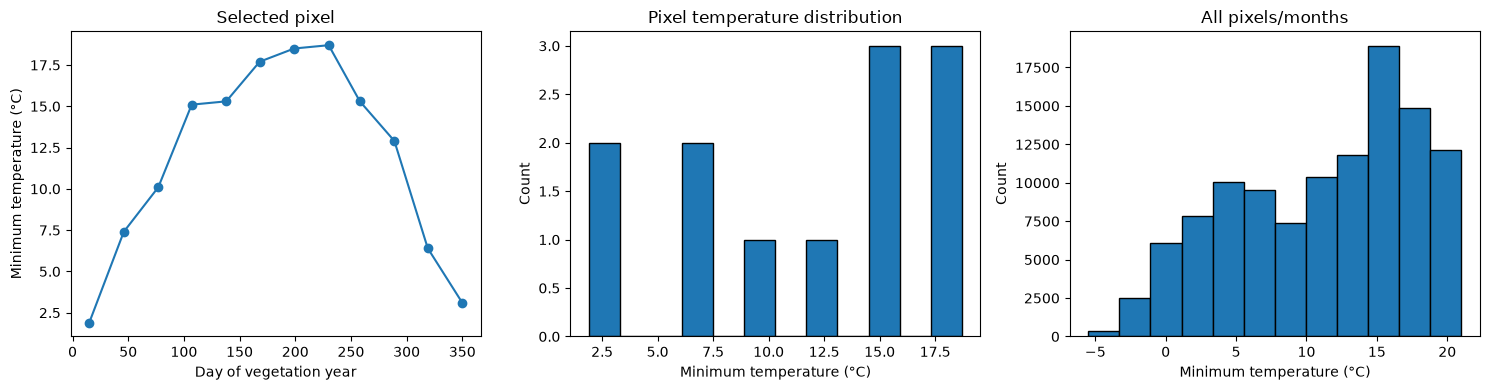

In [19]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4)
)

# --------------------------------------------------
# 1. Pixel temperature curve
# --------------------------------------------------

axes[0].plot(
    doy,
    pixel,
    "o-"
)

axes[0].set_xlabel("Day of vegetation year")
axes[0].set_ylabel("Minimum temperature (°C)")
axes[0].set_title("Selected pixel")


# --------------------------------------------------
# 2. Histogram of selected pixel
# --------------------------------------------------

axes[1].hist(
    pixel[~np.isnan(pixel)],
    bins=12,
    edgecolor="black"
)

axes[1].set_xlabel("Minimum temperature (°C)")
axes[1].set_ylabel("Count")
axes[1].set_title("Pixel temperature distribution")


# --------------------------------------------------
# 3. Histogram of all pixels/months
# --------------------------------------------------

# Can we assume minimum monthly temperature is normally distributed? Let's check with a histogram.
axes[2].hist(
    tmmns[~np.isnan(tmmns)],
    bins=12,
    edgecolor="black"
)

axes[2].set_xlabel("Minimum temperature (°C)")
axes[2].set_ylabel("Count")
axes[2].set_title("All pixels/months")


plt.tight_layout()
plt.show()

## 2. Fitting a GAM and extracting the vegetation period onset and end

Now we fit a GAM and extract vegetation onset and end when the predicted minimum daily temperature crosses 5 degrees. I works for southern, northern hemisphere and equator, i.e. also correctly detects whole year or no vegetation period.

### One pixel example

In [20]:
# --------------------------------------------------
# Fit GAM
# --------------------------------------------------

gam = LinearGAM(
    s(0, n_splines=4, spline_order=3, basis='cp')
).fit(doy[:, None], pixel)


# --------------------------------------------------
# Predict daily temperatures
# --------------------------------------------------

start_date = datetime(years[0], months[0], 1)
# End of vegetation year (last day of last month)
next_month = datetime(
    years[-1] + (months[-1] == 12),
    months[-1] % 12 + 1,
    1
)
end_date = next_month - timedelta(days=1)

n_days = (end_date - start_date).days + 1

days = np.arange(1, n_days + 1)

pred = gam.predict(days[:, None])

print(f"Start date: {start_date}, End date: {end_date}, Number of days: {n_days}")


# --------------------------------------------------
# Convert vegetation-year DOY to actual dates
# --------------------------------------------------

date_days = np.array([
    start_date + timedelta(days=int(d - 1))
    for d in days
])

date_doy = np.array([
    start_date + timedelta(days=int(d - 1))
    for d in doy
])

# --------------------------------------------------
# Vegetation period
# --------------------------------------------------

threshold = 5

above = pred >= threshold

if np.any(above):
    onset = days[np.argmax(above)]
    end = days[len(days) - np.argmax(above[::-1]) - 1]

    onset_date_veg = start_date + timedelta(days=int(onset - 1))
    end_date_veg = start_date + timedelta(days=int(end - 1))

    print(f"Onset: {onset_date_veg.strftime('%Y-%m-%d')}")
    print(f"End: {end_date_veg.strftime('%Y-%m-%d')}")
    print(f"Length: {end - onset + 1} days")

else:
    print("No vegetation period detected")

Start date: 2002-07-01 00:00:00, End date: 2003-06-30 00:00:00, Number of days: 365
Onset: 2002-07-01
End: 2003-06-30
Length: 365 days


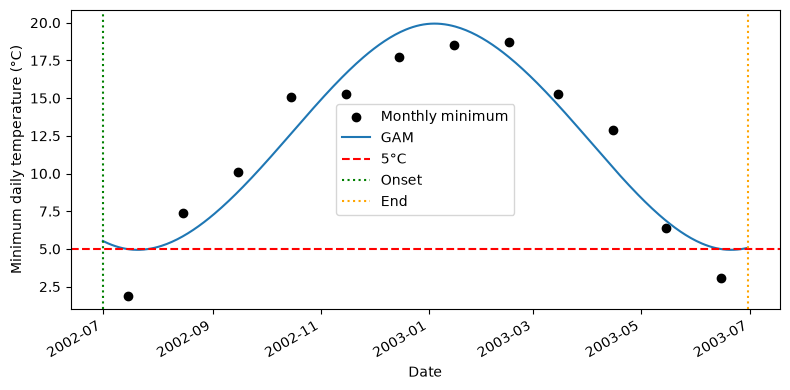

In [21]:
plt.figure(figsize=(8, 4))

plt.scatter(
    date_doy,
    pixel,
    c="black",
    label="Monthly minimum"
)

plt.plot(
    date_days,
    pred,
    label="GAM"
)

plt.axhline(
    threshold,
    ls="--",
    c="red",
    label="5°C"
)

if np.any(above):
    plt.axvline(onset_date_veg, ls=":", c="green", label="Onset")
    plt.axvline(end_date_veg, ls=":", c="orange", label="End")

plt.xlabel("Date")
plt.ylabel("Minimum daily temperature (°C)")
plt.legend()

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

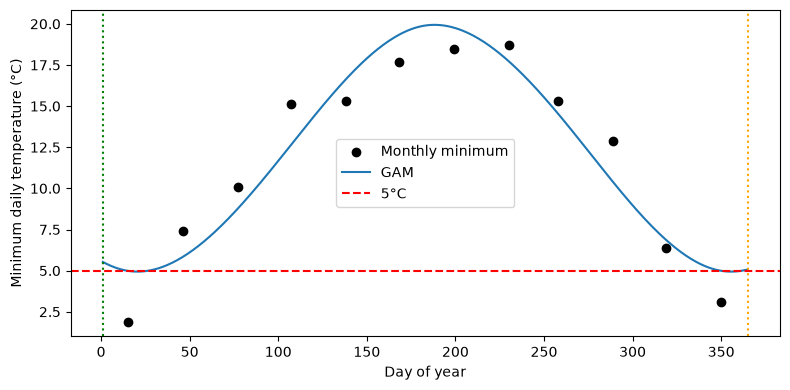

In [22]:
# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(8, 4))
plt.scatter(doy, pixel, c="black", label="Monthly minimum")
plt.plot(days, pred, label="GAM")
plt.axhline(threshold, ls="--", c="red", label="5°C")
plt.axvline(onset, ls=":", c="green")
plt.axvline(end, ls=":", c="orange")

plt.xlabel("Day of year")
plt.ylabel("Minimum daily temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

### Window example

In [23]:
# --------------------------------------------------
# Prepare output arrays
# --------------------------------------------------

n_rows = tmmns.shape[1]
n_cols = tmmns.shape[2]

onset_map = np.full((n_rows, n_cols), np.nan)
end_map = np.full((n_rows, n_cols), np.nan)
length_map = np.full((n_rows, n_cols), np.nan)

# --------------------------------------------------
# Predict days of year
# --------------------------------------------------

start_date = datetime(years[0], months[0], 1)
# End of vegetation year (last day of last month)
next_month = datetime(
    years[-1] + (months[-1] == 12),
    months[-1] % 12 + 1,
    1
)
end_date = next_month - timedelta(days=1)

n_days = (end_date - start_date).days + 1

days = np.arange(1, n_days + 1)


# --------------------------------------------------
# Fit GAM for every pixel
# --------------------------------------------------

threshold = 5

start_time = time.time()

for row in range(n_rows):
    for col in range(n_cols):

        # Extract annual temperature curve
        pixel_temp = tmmns[:, row, col]

        # Skip masked pixels
        if np.isnan(pixel_temp).any(): # np.any(pixel_temp == -999.9) or
            continue

        # Fit GAM
        gam = LinearGAM(
            s(0, n_splines=4, spline_order=3, basis="cp")
        )

        gam.fit(
            doy[:, None],
            pixel_temp
        )

        # Predict daily temperatures
        pred = gam.predict(days[:, None])

        # Threshold crossing
        above = pred >= threshold

        """
        # Skip pixels that never reach threshold
        if not np.any(above):
            continue

        onset = days[np.argmax(above)]
        end = days[len(days) - np.argmax(above[::-1]) - 1]

        onset_map[row, col] = onset
        end_map[row, col] = end
        """

        above = pred >= threshold

        if np.any(above):

            onset = days[np.argmax(above)]
            end = days[len(days) - np.argmax(above[::-1]) - 1]

            onset_map[row, col] = onset
            end_map[row, col] = end
            length_map[row, col] = end - onset + 1

        else:
            onset_map[row, col] = np.nan
            end_map[row, col] = np.nan
            length_map[row, col] = 0
                
runtime = time.time() - start_time

print(f"Finished fitting GAMs in {runtime:.2f} seconds")
print(f"Average time per pixel: {runtime / (n_rows*n_cols):.4f} seconds")

Finished fitting GAMs in 24.71 seconds
Average time per pixel: 0.0025 seconds


In [24]:
# estimate duration for 4 million pixels (global) for one year
runtime_per_pixel = runtime / (n_rows * n_cols)
total_number_of_pixels = 4000000
estimated_hours = (runtime_per_pixel * total_number_of_pixels) / 3600
print(estimated_hours)

2.7450963391198053


In [25]:
# Read elevation data

elevation_path = '/Volumes/TOSHIBA EXT/non-equilibrium/data/elevation/Elevation_resampled_masked_2010-01-01.tif'

# --------------------------------------------------
# Read matching elevation window
# --------------------------------------------------

with rasterio.open(elevation_path) as src:
    elevation = src.read(
        1,
        window=(
            (row_min, row_max),
            (col_min, col_max)
        )
    )

# Mask no-data values
elevation = np.where(elevation == -9999, np.nan, elevation)

/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_64303/2922779880.py:10: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  elevation = src.read(


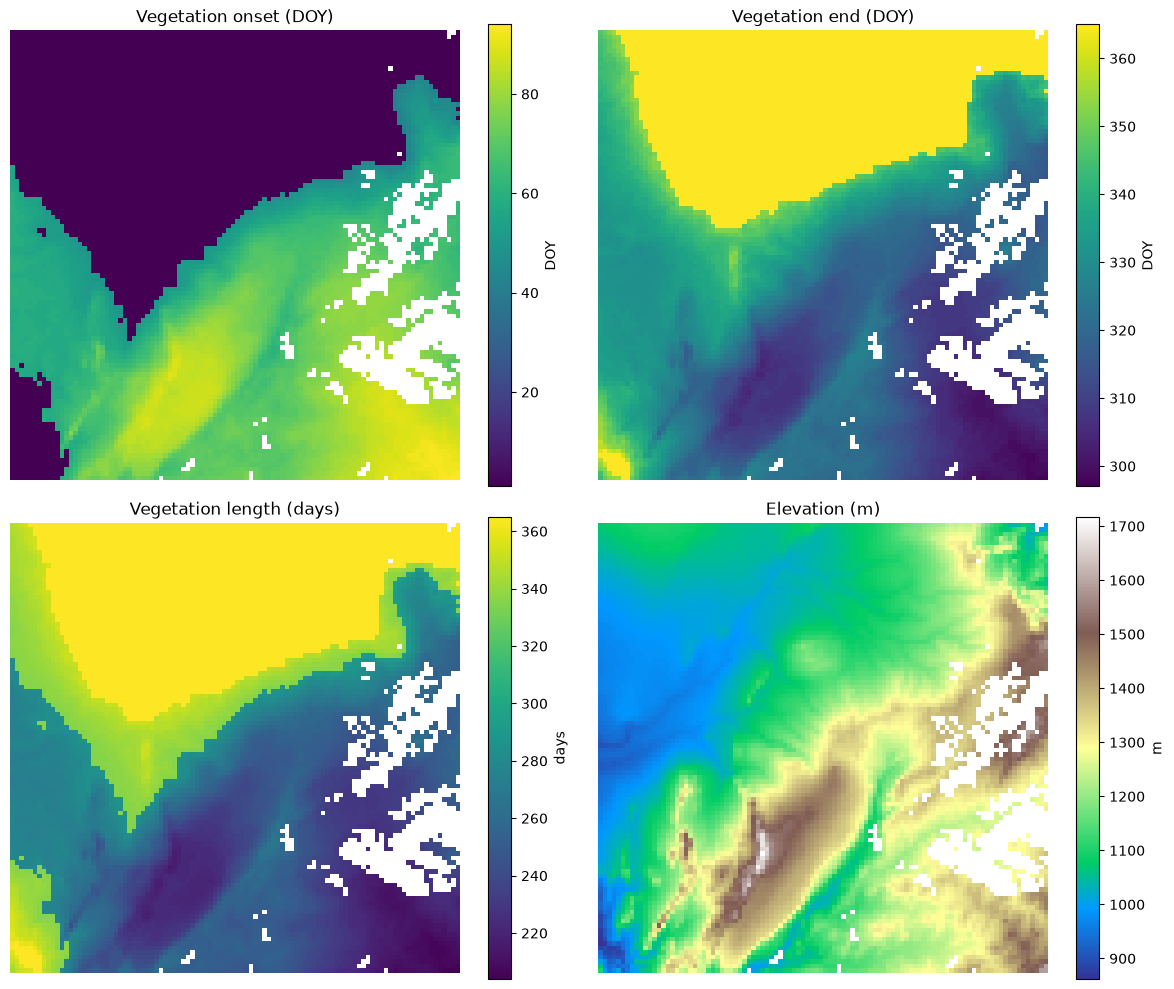

In [26]:
# --------------------------------------------------
# Plot elevation + vegetation period maps
# --------------------------------------------------

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10)
)

im0 = axes[0, 0].imshow(
    onset_map,
    cmap="viridis"
)
axes[0, 0].set_title("Vegetation onset (DOY)")
plt.colorbar(im0, ax=axes[0, 0], label="DOY")


im1 = axes[0, 1].imshow(
    end_map,
    cmap="viridis"
)
axes[0, 1].set_title("Vegetation end (DOY)")
plt.colorbar(im1, ax=axes[0, 1], label="DOY")


im2 = axes[1, 0].imshow(
    length_map,
    cmap="viridis"
)
axes[1, 0].set_title("Vegetation length (days)")
plt.colorbar(im2, ax=axes[1, 0], label="days")


im3 = axes[1, 1].imshow(
    elevation,
    cmap="terrain"
)
axes[1, 1].set_title("Elevation (m)")
plt.colorbar(im3, ax=axes[1, 1], label="m")


for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [27]:

# --------------------------------------------------
# Read exported vegetation period raster
# --------------------------------------------------

window = Window(
    col_off=col_min,
    row_off=row_min,
    width=col_max - col_min,
    height=row_max - row_min
)

with rasterio.open("vegetation_period_2002.tif") as src:

    onset_map_tif = src.read(1, window=window)
    end_map_tif = src.read(2, window=window)
    length_map_tif = src.read(3, window=window)

    #nodata = src.nodata

# Mask NoData values
""" 
if nodata is not None:
    onset_map = np.where(onset_map == nodata, np.nan, onset_map)
    end_map = np.where(end_map == nodata, np.nan, end_map)
    length_map = np.where(length_map == nodata, np.nan, length_map)
"""

/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_64303/712637477.py:14: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  onset_map_tif = src.read(1, window=window)
/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_64303/712637477.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  end_map_tif = src.read(2, window=window)
/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_64303/712637477.py:16: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  length_map_tif = src.read(3, window=window)


' \nif nodata is not None:\n    onset_map = np.where(onset_map == nodata, np.nan, onset_map)\n    end_map = np.where(end_map == nodata, np.nan, end_map)\n    length_map = np.where(length_map == nodata, np.nan, length_map)\n'

In [28]:
from pyproj import Transformer

# WGS84 -> raster CRS
transformer = Transformer.from_crs(
    "EPSG:4326",
    src.crs,
    always_xy=True
)

# Point on the equator (0°N, 0°E)
x_eq, y_eq = transformer.transform(0, 0)

# Row containing the equator
equator_row, _ = rowcol(src.transform, x_eq, y_eq)

# Convert to row within the example window
equator_row_window = equator_row - row_min

print(equator_row_window)

-547


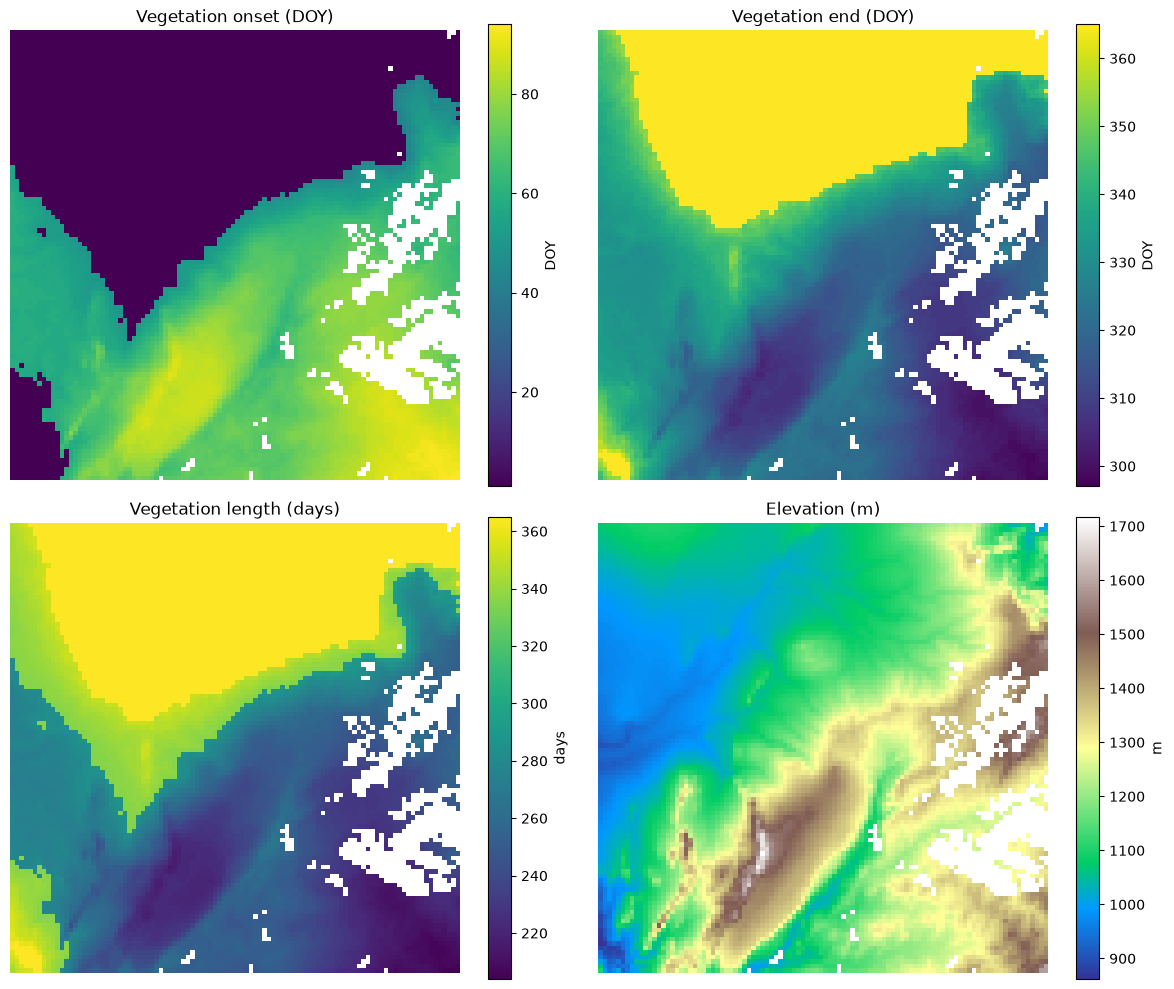

In [29]:
# --------------------------------------------------
# Plot elevation + vegetation period maps
# --------------------------------------------------

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10)
)

im0 = axes[0, 0].imshow(
    onset_map_tif,
    cmap="viridis"
)
axes[0, 0].set_title("Vegetation onset (DOY)")
plt.colorbar(im0, ax=axes[0, 0], label="DOY")


im1 = axes[0, 1].imshow(
    end_map_tif,
    cmap="viridis"
)
axes[0, 1].set_title("Vegetation end (DOY)")
plt.colorbar(im1, ax=axes[0, 1], label="DOY")


im2 = axes[1, 0].imshow(
    length_map_tif,
    cmap="viridis"
)
axes[1, 0].set_title("Vegetation length (days)")
plt.colorbar(im2, ax=axes[1, 0], label="days")


im3 = axes[1, 1].imshow(
    elevation,
    cmap="terrain"
)
axes[1, 1].set_title("Elevation (m)")
plt.colorbar(im3, ax=axes[1, 1], label="m")
""" 
axes[0, 0].axhline(equator_row_window, color="red", lw=2)
axes[0, 1].axhline(equator_row_window, color="red", lw=2)
axes[1, 0].axhline(equator_row_window, color="red", lw=2)
axes[1, 1].axhline(equator_row_window, color="red", lw=2)
"""

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()


## Questions for Henrik:
- remember: currently we just take the first and the last crossing of 8 degrees, so assume 1 veg period
- we have only min and max monthly temperature: do we "average" it first, then fit the gam, or fit the gam for max and min separately and then average on the day? and can we really assume that the min and max temperature both happen in the middle of the month?
    - minimale temperatur, wir nehmen an sie passiert in der mitte vom monat, und 5 grad als threshold für onset und end
- how to specify the gam? how many splines etc?
    - eine polynomial funktion kann man auch mal ausprobieren
- what do we do about the southern hempishpere where the vegetation period might cross the year boundary? 
    - fitting one gam for all 25 years combined? or a moving window?
    - für südhalbkugel monate 6-18 nehmen

Karte für alle pixel für 1 jahr
100 mal 100 ausprobieren altai in zentralasien

2 prios: dass es zeitnah fertig wird und dass ich was lerne 

instats: paar kurse ausprobieren hochzuladen 

## New questions for Henrik:
- which distribution do we assume for minimum temperature? to specify the distribution in the gam correctly
- do we need proper validation for number and order of splines?
- can i use your mac? do i need to install python and everything?

## To do:
1. take minimum temperature, assume it happens in the middle of the month, take 5 degrees as threshold for onset and end - DONE
2. try a gam with polynomial function, different splines - DONE
   - 3 splines order 2, or 4 splines order 3 seem good; I assume temperatures to be normally distributed, therefore linearGAM
3. adapt code to be flexible with leap years - DONE - CHECK AGAIN LATER
    - should work now, but check again with actual leap year data, e.g. 2004
4. extend spatially: write code to try it on an example region of 100x100 pixels in a mountaineous region in central asia like the altai - DONE
5. make a map that shows the vegetation period for the pixels in the example region - DONE
6. extend temporally: write code to take months 1-12 for north of globe and 6-18 for south of globe (bc in southern hemisphere the veg period crosses the year boundary; equator doesn't matter because it's always above 5 degrees anyways); check if it works as well for equator when the vegetation period is the whole year - DONE
7. extend spatially: write code for global -> try parallel processing or chunks?
8. save the vegetation period information in a modis raster (or table?) iteratively 

Nach der Pause:
- -9999 in NAs konvertieren / ignorieren 
- loop schreiben
- map 
- compare with elevation